# Week 5 — Unsupervised Learning: K-Means & DBSCAN Clustering

**AI Training Program — Beginner to Practitioner | Phase 2: Intro to ML/DL**

### What you'll learn in this notebook

1. What clustering is, and why it's different from everything you've done so far (regression/classification)
2. **K-Means** — the intuition, the math, and the algorithm built from scratch
3. How to pick the right number of clusters (**Elbow Method** & **Silhouette Score**)
4. **DBSCAN** — density-based clustering, and why it solves problems K-Means can't
5. A hands-on **customer segmentation** project tying it all together

**Prerequisites:** Python, NumPy, Pandas, Matplotlib (Weeks 1-4). No prior ML knowledge needed.

> 💡 Run the cells from top to bottom. Each section builds on the previous one.


## 1. What is Clustering?

So far in this program, every model you've trained has learned from **labeled** data — you gave it inputs *and* the correct answers (this is called **supervised learning**).

Clustering is different. It's a form of **unsupervised learning**: you give the algorithm data with **no labels at all**, and it has to find structure on its own. Specifically, clustering groups data points so that:

- Points in the **same** group (cluster) are as *similar* to each other as possible
- Points in **different** groups are as *different* from each other as possible

There's no "correct answer" to check against — the algorithm just looks for natural groupings in the data.

### Where clustering shows up in the real world

| Use case | What gets clustered |
|---|---|
| **Customer segmentation** | Group customers by income/spending to target marketing |
| **Anomaly / fraud detection** | Points that don't fit any cluster are flagged as outliers |
| **Image compression** | Group similar pixel colors and replace each group with one representative color |
| **Document / topic clustering** | Group news articles or support tickets by topic |
| **Biology & genetics** | Group genes or species with similar expression patterns |

Today we'll cover the two most important clustering algorithms you'll encounter as a practitioner: **K-Means** (the default first choice) and **DBSCAN** (for when K-Means' assumptions break down).


In [1]:
# Core libraries for this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.datasets import make_blobs, make_moons
from sklearn.neighbors import NearestNeighbors

# Consistent plot styling
plt.rcParams['figure.figsize'] = (8, 5)
sns.set_style('whitegrid')
np.random.seed(42)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. K-Means Clustering — Intuition

K-Means is the most widely used clustering algorithm because it's simple, fast, and usually a great first attempt. The idea:

1. **Choose K** — decide how many clusters you want to find (you pick this number up front)
2. **Initialize** — randomly place K "centroids" (imaginary center points) in the data space
3. **Assign** — put each data point into the cluster of its *nearest* centroid (using Euclidean distance)
4. **Update** — move each centroid to the *average* (mean) position of all points assigned to it — this is where the name comes from
5. **Repeat** steps 3-4 until the centroids stop moving (**convergence**)

Mathematically, K-Means tries to minimize the **within-cluster sum of squares (WCSS)**, also called **inertia**:

$$ J = \sum_{i=1}^{K} \sum_{x \in C_i} \lVert x - \mu_i \rVert ^2 $$

where $\mu_i$ is the centroid of cluster $C_i$. In plain English: *add up the squared distance from every point to its own cluster's center, and make that total as small as possible.*

Let's watch this happen step by step on a small synthetic dataset.


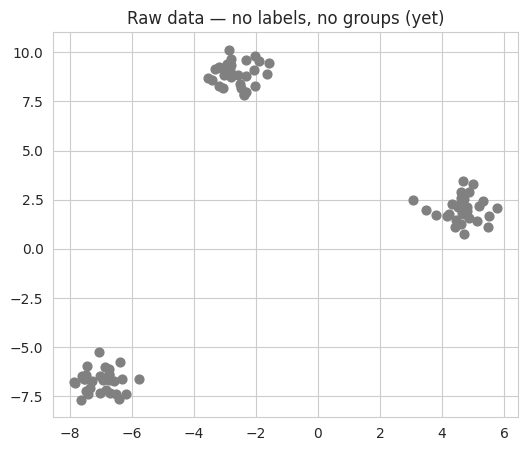

In [2]:
# A small toy dataset with 3 obvious visual groups
X_toy, _ = make_blobs(n_samples=90, centers=3, cluster_std=0.60, random_state=42)

plt.figure(figsize=(6, 5))
plt.scatter(X_toy[:, 0], X_toy[:, 1], s=40, color='gray')
plt.title("Raw data — no labels, no groups (yet)")
plt.show()


Notice the centroids barely move after iteration 2 — that's convergence.


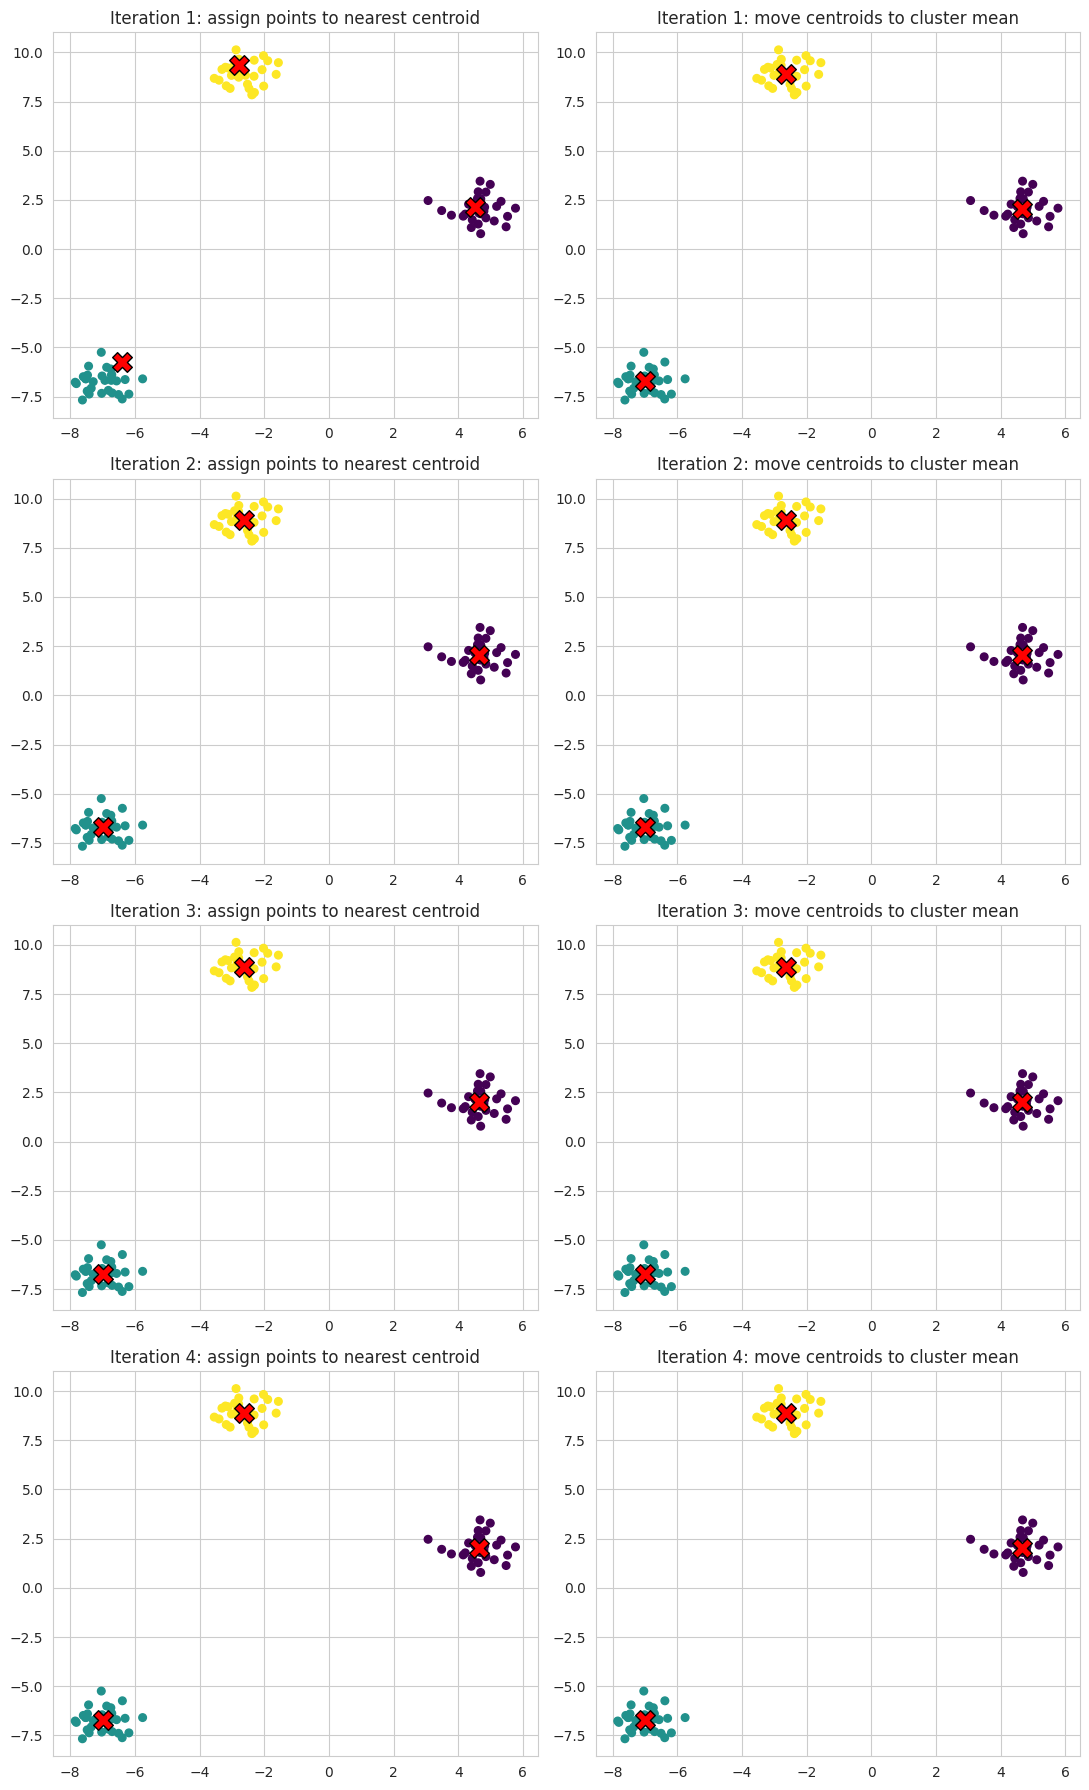

In [3]:
# Manually run the K-Means algorithm for 4 iterations so you can see EXACTLY
# what scikit-learn does internally when you call .fit()

k = 3
rng = np.random.default_rng(42)
initial_idx = rng.choice(len(X_toy), k, replace=False)
centroids = X_toy[initial_idx].copy()

fig, axes = plt.subplots(4, 2, figsize=(11, 18))

for it in range(4):
    # --- Assignment step: give every point to its nearest centroid ---
    distances = np.linalg.norm(X_toy[:, None, :] - centroids[None, :, :], axis=2)
    labels = distances.argmin(axis=1)

    ax = axes[it, 0]
    ax.scatter(X_toy[:, 0], X_toy[:, 1], c=labels, cmap='viridis', s=30)
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, edgecolor='black')
    ax.set_title(f"Iteration {it+1}: assign points to nearest centroid")

    # --- Update step: move each centroid to the mean of its assigned points ---
    new_centroids = np.array([
        X_toy[labels == j].mean(axis=0) if np.any(labels == j) else centroids[j]
        for j in range(k)
    ])

    ax = axes[it, 1]
    ax.scatter(X_toy[:, 0], X_toy[:, 1], c=labels, cmap='viridis', s=30)
    ax.scatter(new_centroids[:, 0], new_centroids[:, 1], c='red', marker='X', s=200, edgecolor='black')
    ax.set_title(f"Iteration {it+1}: move centroids to cluster mean")

    centroids = new_centroids

plt.tight_layout()
plt.show()
print("Notice the centroids barely move after iteration 2 — that's convergence.")


That loop **is** K-Means. Scikit-learn's `KMeans` class does exactly this internally (plus a smarter initialization called **k-means++**, and it repeats the whole process `n_init` times with different starting points, keeping the best result — since a bad random start can get stuck in a poor local minimum).

Now let's use the real library on a practical project.

## 3. Project Dataset — Customer Segmentation

We'll build a customer segmentation model, similar to the classic "Mall Customer Segmentation" dataset used in retail analytics. To keep this notebook self-contained and runnable anywhere, we'll **simulate** a dataset with the same structure and realistic patterns: `Age`, `Annual Income (k$)`, and `Spending Score (1-100)` — a 1-100 score the mall assigns based on customer behavior and purchase data.

*(If you have the real `Mall_Customers.csv` from Kaggle, you can swap it in with `pd.read_csv('Mall_Customers.csv')` — the rest of the notebook works unchanged.)*


In [4]:
np.random.seed(42)
n_customers = 200

# Simulate 5 natural customer segments so the data has realistic, learnable structure
# (n, income_mean, income_std, spending_mean, spending_std)
segment_params = [
    (40, 25, 5, 20, 10),   # low income, low spending
    (40, 25, 5, 80, 10),   # low income, high spending ("impulsive")
    (40, 55, 8, 50, 12),   # mid income, mid spending ("standard")
    (40, 85, 8, 15, 10),   # high income, low spending ("careful")
    (40, 90, 8, 85, 8),    # high income, high spending ("target/premium")
]

incomes, spends = [], []
for n, income_mean, income_std, spend_mean, spend_std in segment_params:
    incomes.append(np.random.normal(income_mean, income_std, n))
    spends.append(np.random.normal(spend_mean, spend_std, n))

annual_income = np.clip(np.concatenate(incomes), 15, 140)
spending_score = np.clip(np.concatenate(spends), 1, 100)
age = np.random.randint(18, 70, n_customers)
gender = np.random.choice(['Male', 'Female'], n_customers)

df = pd.DataFrame({
    'CustomerID': range(1, n_customers + 1),
    'Gender': gender,
    'Age': age,
    'Annual Income (k$)': annual_income.round(1),
    'Spending Score (1-100)': spending_score.round(0).astype(int)
})
df = df.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle so segments aren't in order

df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,96,Female,65,61.6,59
1,16,Male,27,22.2,29
2,31,Female,57,22.0,24
3,159,Female,43,85.6,18
4,129,Male,58,99.1,18


In [5]:
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,42.750000,55.593500,51.140000
std,57.879185,15.350757,28.695373,30.639095
min,1.000000,18.000000,15.200000,1.000000
25%,50.750000,30.750000,25.825000,22.000000
50%,100.500000,42.500000,55.850000,53.500000
75%,150.250000,55.250000,83.650000,81.000000
max,200.000000,69.000000,106.700000,100.000000


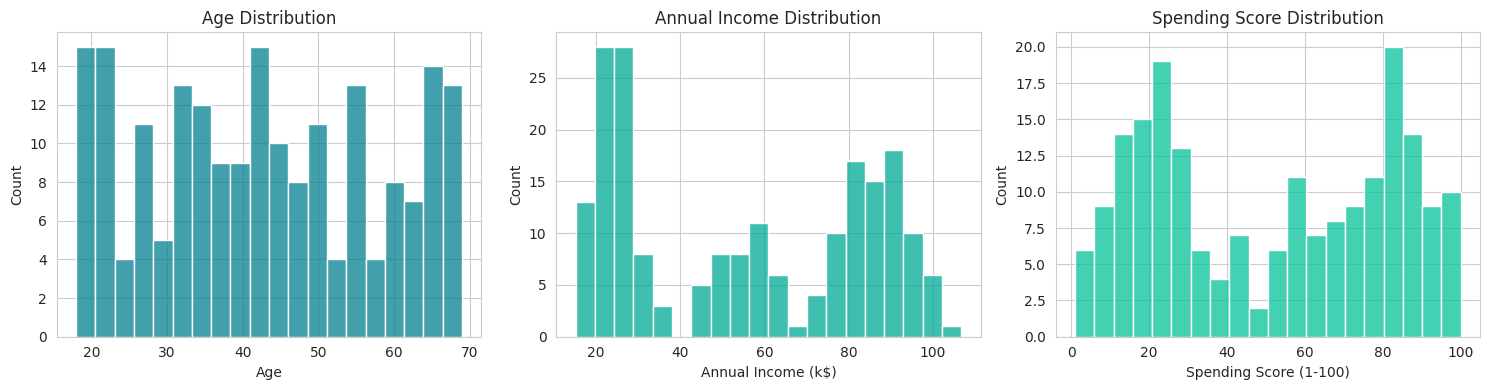

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], bins=20, ax=axes[0], color='#028090')
axes[0].set_title('Age Distribution')
sns.histplot(df['Annual Income (k$)'], bins=20, ax=axes[1], color='#00A896')
axes[1].set_title('Annual Income Distribution')
sns.histplot(df['Spending Score (1-100)'], bins=20, ax=axes[2], color='#02C39A')
axes[2].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()


Can you already spot roughly 5 visual groupings? That's exactly what clustering finds automatically.


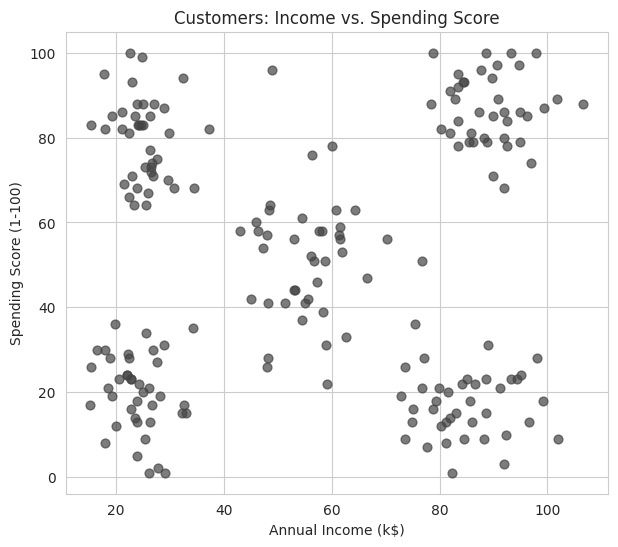

In [7]:
plt.figure(figsize=(7, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], s=40, alpha=0.7, color='#444444')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customers: Income vs. Spending Score')
plt.show()

print("Can you already spot roughly 5 visual groupings? That's exactly what clustering finds automatically.")


## 4. Feature Scaling (don't skip this!)

Both K-Means and DBSCAN measure **distance** between points. If one feature has a much bigger numeric range than another (e.g., income in the 15-140 range vs. a 0-1 feature), it will dominate the distance calculation purely because of its scale — not because it's actually more important.

We fix this with **standardization**: rescale every feature to have mean 0 and standard deviation 1.

$$ z = \frac{x - \mu}{\sigma} $$


In [8]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling -> mean:", X.mean(axis=0).round(2), " std:", X.std(axis=0).round(2))
print("After scaling  -> mean:", X_scaled.mean(axis=0).round(2), " std:", X_scaled.std(axis=0).round(2))


Before scaling -> mean: [55.59 51.14]  std: [28.62 30.56]
After scaling  -> mean: [ 0. -0.]  std: [1. 1.]


## 5. Choosing K — Elbow Method & Silhouette Score

K-Means makes you choose the number of clusters, `K`, *before* it runs. Two standard techniques help you pick a good value.

**Elbow Method:** plot inertia (WCSS) against K. Inertia always decreases as K increases (more clusters = tighter fit), but the *rate* of improvement drops sharply at some point — that "elbow" is a good candidate for K.

**Silhouette Score:** for each point, compares how close it is to its own cluster vs. the nearest other cluster. Ranges from -1 (wrong cluster) to +1 (perfectly matched); scores near 0 mean overlapping clusters. Unlike inertia, higher is better and it doesn't automatically favor larger K, making it a good tie-breaker.


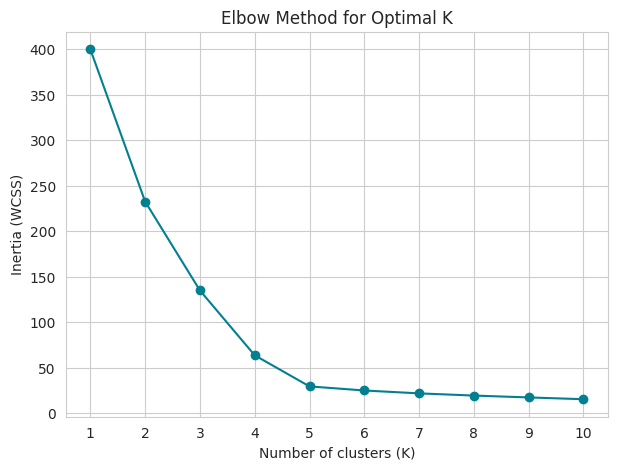

In [9]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(list(K_range), inertias, marker='o', color='#028090')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method for Optimal K')
plt.xticks(list(K_range))
plt.show()


Best K by silhouette score: 5  (score = 0.661)


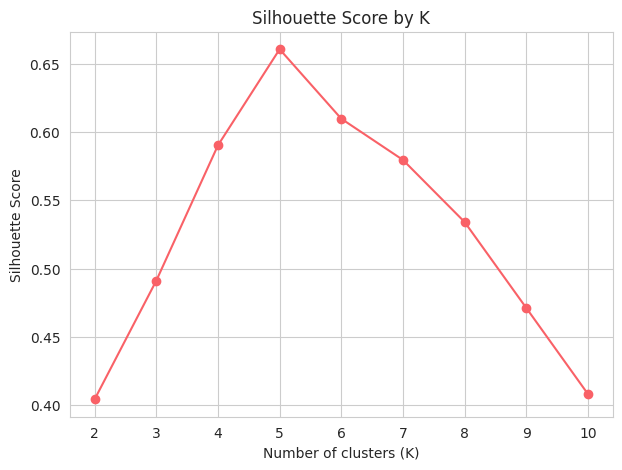

In [10]:
sil_scores = []
K_range2 = range(2, 11)
for k in K_range2:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 5))
plt.plot(list(K_range2), sil_scores, marker='o', color='#F96167')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score by K')
plt.xticks(list(K_range2))
plt.show()

best_k = list(K_range2)[np.argmax(sil_scores)]
print(f"Best K by silhouette score: {best_k}  (score = {max(sil_scores):.3f})")


Both methods agree: **K = 5** is the sweet spot here — which makes sense, since we designed the data with 5 underlying segments. On real data you won't always get such a clean answer, and that's fine: use these plots as *guidance*, combined with domain knowledge about how many segments would actually be useful to act on.

## 6. Final K-Means Model


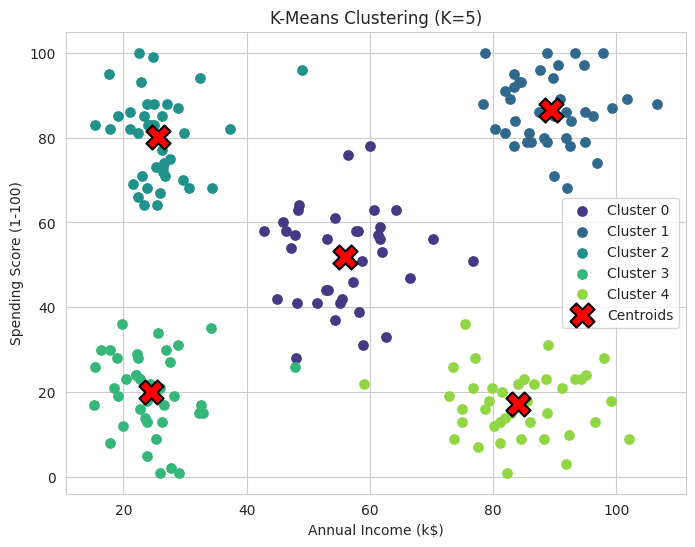

In [11]:
k_final = 5
kmeans = KMeans(n_clusters=k_final, n_init=10, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

# Convert centroids back to the original (unscaled) units for interpretation
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
palette = sns.color_palette('viridis', k_final)
for c in range(k_final):
    pts = df[df['KMeans_Cluster'] == c]
    plt.scatter(pts['Annual Income (k$)'], pts['Spending Score (1-100)'],
                s=45, label=f'Cluster {c}', color=palette[c])

plt.scatter(centers_original[:, 0], centers_original[:, 1],
            s=300, c='red', marker='X', edgecolor='black', linewidth=1.5, label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'K-Means Clustering (K={k_final})')
plt.legend()
plt.show()


In [12]:
cluster_summary = df.groupby('KMeans_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_summary['Count'] = df['KMeans_Cluster'].value_counts()
cluster_summary


,Age,Annual Income (k$),Spending Score (1-100),Count
KMeans_Cluster,,,,
0,38.0,55.9,51.8,38
1,43.6,89.4,86.6,40
2,46.4,25.6,80.0,41
3,40.7,24.5,20.0,41
4,44.8,84.1,17.3,40


Reading the table above, you can label each cluster in business terms, for example:

- **Low income, low spending** — price-sensitive, budget-conscious shoppers
- **Low income, high spending** — impulsive spenders relative to their income
- **Mid income, mid spending** — the "average" customer
- **High income, low spending** — careful/sensible; a target for engagement campaigns
- **High income, high spending** — your premium customers; prioritize retention

This is the entire point of clustering: turning raw numbers into groups a marketing or product team can actually act on.

## 7. Where K-Means Breaks Down

K-Means has real limitations you should know as a practitioner:

- **You must choose K in advance** — the elbow/silhouette methods help, but there's no guaranteed "correct" answer
- **Assumes roughly spherical, similarly-sized clusters** — because it only compares distance to a single center point, it can't represent elongated or irregular shapes
- **Sensitive to outliers** — a single far-away point can drag a centroid away from its cluster's true center
- **Sensitive to initialization** — mitigated in practice by k-means++ and `n_init`, but not eliminated

Let's *see* the spherical-cluster assumption fail on purpose, using two interleaving crescent moon shapes.


K-Means can only draw straight-line boundaries between centroids, so it can't separate curved shapes.


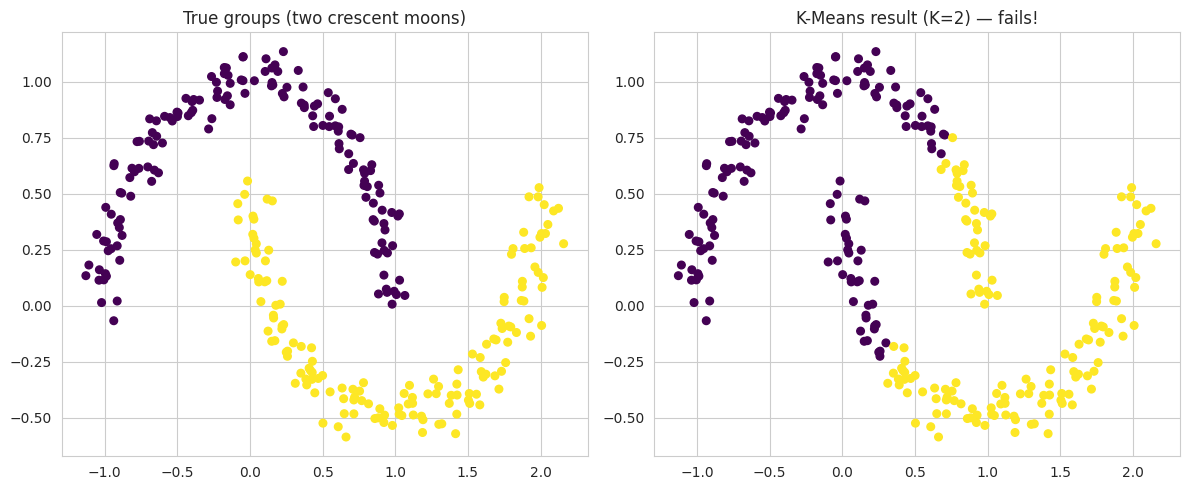

In [13]:
X_moons, y_moons = make_moons(n_samples=300, noise=0.06, random_state=42)

kmeans_moons = KMeans(n_clusters=2, n_init=10, random_state=42)
labels_km_moons = kmeans_moons.fit_predict(X_moons)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', s=30)
axes[0].set_title('True groups (two crescent moons)')
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=labels_km_moons, cmap='viridis', s=30)
axes[1].set_title('K-Means result (K=2) — fails!')
plt.tight_layout()
plt.show()

print("K-Means can only draw straight-line boundaries between centroids, so it can't separate curved shapes.")


## 8. DBSCAN — Density-Based Clustering

**DBSCAN** (Density-Based Spatial Clustering of Applications with Noise) takes a completely different approach: instead of comparing points to a center, it groups together points that are packed closely (**dense regions**), and marks points sitting alone in low-density regions as **noise/outliers**.

### Key parameters

- **`eps` (ε):** the radius used to search for neighboring points around each point
- **`min_samples`:** the minimum number of points (including itself) required within `eps` to call a point "dense"

### Point types

- **Core point:** has at least `min_samples` points within distance `eps` of it
- **Border point:** has fewer than `min_samples` neighbors, but sits within `eps` of a core point
- **Noise point:** neither of the above — it's not close enough to any dense region

### The algorithm

1. Pick an unvisited point. Count its neighbors within `eps`.
2. If it has ≥ `min_samples` neighbors, it's a **core point** — start a new cluster and recursively add all points density-reachable from it (this is how a cluster can "snake" through an irregular shape).
3. If it doesn't qualify as core but lies within `eps` of a core point, it joins that cluster as a **border point**.
4. Otherwise, label it **noise** (`-1`).
5. Repeat until every point has been visited.

Unlike K-Means, **you never specify the number of clusters** — DBSCAN discovers it from the data's density structure. Let's watch it succeed exactly where K-Means failed.


Unique cluster labels: [0 1]
(-1 means noise: not assigned to any cluster)


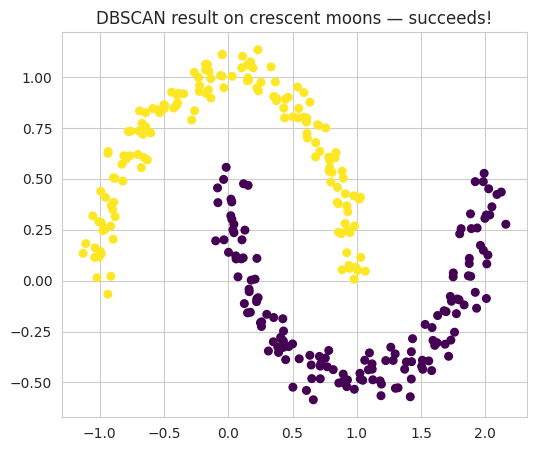

In [14]:
dbscan_moons = DBSCAN(eps=0.2, min_samples=5)
labels_db_moons = dbscan_moons.fit_predict(X_moons)

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_db_moons, cmap='viridis', s=30)
plt.title('DBSCAN result on crescent moons — succeeds!')
plt.show()

print("Unique cluster labels:", np.unique(labels_db_moons))
print("(-1 means noise: not assigned to any cluster)")


Because DBSCAN follows chains of dense points rather than comparing to a single center, it correctly traces each curved moon as its own cluster — something no fixed-center method like K-Means can do.

### Choosing `eps`: the K-Distance Graph

There's no elbow/silhouette equivalent for DBSCAN, but a common heuristic works well: for each point, compute the distance to its `k`-th nearest neighbor (`k = min_samples`), sort these distances, and plot them. The point where the curve bends sharply upward ("the elbow") is a good starting value for `eps` — beyond that point, distances jump quickly, meaning points are moving from dense regions into sparse ones.


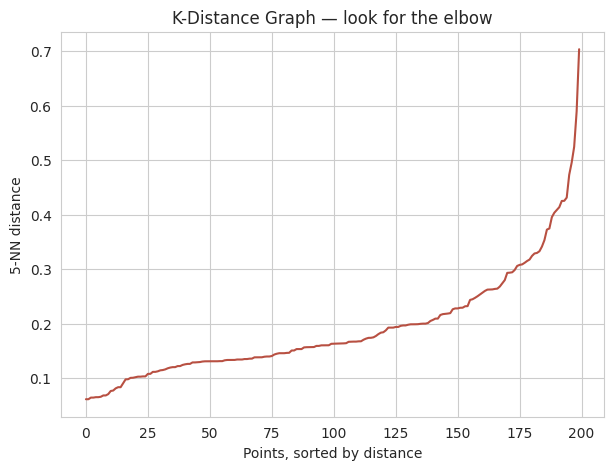

In [15]:
k_neighbors = 5  # match this to your intended min_samples
neighbors = NearestNeighbors(n_neighbors=k_neighbors)
neighbors_fit = neighbors.fit(X_scaled)
distances, _ = neighbors_fit.kneighbors(X_scaled)

k_distances = np.sort(distances[:, k_neighbors - 1])

plt.figure(figsize=(7, 5))
plt.plot(k_distances, color='#B85042')
plt.xlabel('Points, sorted by distance')
plt.ylabel(f'{k_neighbors}-NN distance')
plt.title('K-Distance Graph — look for the elbow')
plt.show()


DBSCAN_Cluster
-1     7
 0    34
 1    40
 2    39
 3    40
 4    40
Name: count, dtype: int64


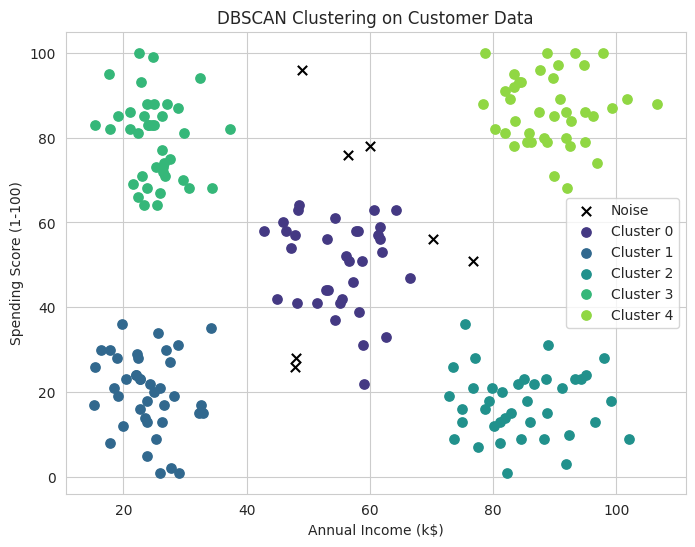

In [16]:
# Based on the elbow above (~0.3), apply DBSCAN to the customer data
dbscan = DBSCAN(eps=0.3, min_samples=5)
df['DBSCAN_Cluster'] = dbscan.fit_predict(X_scaled)

plt.figure(figsize=(8, 6))
unique_labels = sorted(df['DBSCAN_Cluster'].unique())
palette = sns.color_palette('viridis', len(unique_labels) - (1 if -1 in unique_labels else 0))

color_idx = 0
for label in unique_labels:
    pts = df[df['DBSCAN_Cluster'] == label]
    if label == -1:
        plt.scatter(pts['Annual Income (k$)'], pts['Spending Score (1-100)'],
                    s=45, color='black', marker='x', label='Noise')
    else:
        plt.scatter(pts['Annual Income (k$)'], pts['Spending Score (1-100)'],
                    s=45, color=palette[color_idx], label=f'Cluster {label}')
        color_idx += 1

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clustering on Customer Data')
plt.legend()
plt.show()

print(df['DBSCAN_Cluster'].value_counts().sort_index())


## 9. K-Means vs. DBSCAN — Side by Side


In [17]:
kmeans_sil = silhouette_score(X_scaled, df['KMeans_Cluster'])

mask = df['DBSCAN_Cluster'] != -1
if mask.sum() > 0 and df.loc[mask, 'DBSCAN_Cluster'].nunique() > 1:
    dbscan_sil = silhouette_score(X_scaled[mask], df.loc[mask, 'DBSCAN_Cluster'])
    dbscan_sil_str = f"{dbscan_sil:.3f}"
else:
    dbscan_sil_str = "N/A"

n_noise = (df['DBSCAN_Cluster'] == -1).sum()

print(f"K-Means  -> clusters: {df['KMeans_Cluster'].nunique()}, silhouette: {kmeans_sil:.3f}, noise points: 0")
print(f"DBSCAN   -> clusters: {df.loc[mask, 'DBSCAN_Cluster'].nunique()}, silhouette: {dbscan_sil_str}, noise points: {n_noise}")


K-Means  -> clusters: 5, silhouette: 0.661, noise points: 0
DBSCAN   -> clusters: 5, silhouette: 0.685, noise points: 7


| | **K-Means** | **DBSCAN** |
|---|---|---|
| Number of clusters | You must specify `K` | Discovered automatically from density |
| Cluster shape | Assumes spherical/convex | Handles arbitrary shapes |
| Outliers / noise | Every point forced into a cluster | Explicitly labels noise as `-1` |
| Key parameters | `K` (and `n_init`) | `eps`, `min_samples` |
| Sensitivity | Sensitive to outliers and init | Sensitive to `eps`; struggles when cluster densities vary a lot |
| Speed on large data | Fast, scales well | Slower on very large or high-dimensional data |
| Best for | Well-separated, blob-like groups (e.g. this customer data) | Irregular shapes, spatial data, anomaly detection |

### Rule of thumb
Start with **K-Means** when you have a rough idea of how many segments you want and your data looks reasonably "blobby." Reach for **DBSCAN** when clusters might be irregularly shaped, when you expect outliers/noise you want to identify explicitly, or when you have no idea how many clusters there should be.


## 10. Practice Exercises

Try these on your own before moving to next week's material:

1. Re-run K-Means using only `Age` and `Spending Score (1-100)` instead of income and spending. Do the clusters make similar business sense?
2. Change `min_samples` in DBSCAN to 3 and to 10 — how does the number of noise points change? Why?
3. Add a few extreme outlier rows to `df` (e.g., income = 200, spending = 1) and re-run both algorithms. Which one handles the outlier more gracefully?
4. Cluster on all three features (`Age`, `Annual Income (k$)`, `Spending Score (1-100)`) at once. You can't plot 3 dimensions directly on a scatter plot — look up `Axes3D` or try a pairplot colored by cluster.
5. Try `DBSCAN` with the *unscaled* data (skip `StandardScaler`). Do the results change? Why does scaling matter more for DBSCAN than for many other algorithms?

## 11. Summary

- **Clustering** is unsupervised learning: find structure in unlabeled data
- **K-Means** iteratively assigns points to the nearest centroid, then updates centroids to the cluster mean, until convergence — fast, but assumes spherical clusters and needs `K` chosen up front
- Use the **Elbow Method** and **Silhouette Score** together to choose a good `K`
- **DBSCAN** groups points by density, automatically finds the number of clusters, handles irregular shapes, and explicitly flags noise/outliers — but needs careful tuning of `eps` and `min_samples`
- **Always scale your features** before running either algorithm, since both rely on distance calculations
- Real projects often try both and compare — there's rarely a single "correct" algorithm before you've looked at your data

### Next week (Week 6 & 7): Neural Networks, CNNs & RNNs
You'll move from classical ML into deep learning — perceptrons, backpropagation, image classification with CNNs on CIFAR-10, and sequence modeling with RNN/LSTM for stock price forecasting.

### Further reading
- scikit-learn User Guide: [Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- Original DBSCAN paper: Ester et al., *"A Density-Based Algorithm for Discovering Clusters"* (1996)
